## **Analysis with different mu for LFR_benchmark graph**

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from cdlib import algorithms, evaluation
from cdlib.classes.node_clustering import NodeClustering
import random

# check mu from 0.1 to 0.9
mu_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# store results
results = {
    "mu": [],
    "louvain_nmi": [], "louvain_ari": [],
    "infomap_nmi": [], "infomap_ari": [],
    "walktrap_nmi": [], "walktrap_ari": []
}

for mu in mu_values:
    print(f"\nRunning mu={mu}")

    try:
        G = nx.LFR_benchmark_graph(
            n=500,
            tau1=3,
            tau2=1.5,
            mu=mu,
            average_degree=10,
            min_community=10,
            max_iters=10000,
            seed=1
        )
    except Exception as e:
        print(f"  Failed for mu={mu}: {e}")
        continue

    # Basic Info
    print(f"  Nodes: {G.number_of_nodes()}")
    print(f"  Edges: {G.number_of_edges()}")
    print(f"  Is directed: {G.is_directed()}")

    # extract ground truth
    gt_communities = list(set([
        frozenset(G.nodes[v]["community"])
        for v in G.nodes()
    ]))
    print(f"Ground truth communities: {len(gt_communities)}")

    # convert ground truth to cdlib format
    gt = NodeClustering(
            communities=[list(c) for c in gt_communities],
            graph=G,
            method_name="ground_truth"
        )

    # run algorithms
    louvain  = algorithms.louvain(G)
    infomap  = algorithms.infomap(G)
    walktrap = algorithms.walktrap(G)

    # compute NMI and ARI
    results["mu"].append(mu)
    results["louvain_nmi"].append(
        evaluation.normalized_mutual_information(louvain, gt).score)
    results["louvain_ari"].append(
        evaluation.adjusted_rand_index(louvain, gt).score)
    results["infomap_nmi"].append(
        evaluation.normalized_mutual_information(infomap, gt).score)
    results["infomap_ari"].append(
        evaluation.adjusted_rand_index(infomap, gt).score)
    results["walktrap_nmi"].append(
        evaluation.normalized_mutual_information(walktrap, gt).score)
    results["walktrap_ari"].append(
        evaluation.adjusted_rand_index(walktrap, gt).score)


print("\nResults:")

# NMI Results
print("mu  | Louvain NMI | Infomap NMI | Walktrap NMI")
print("----|-------------|-------------|-------------")
for i, mu_val in enumerate(results["mu"]):
    print(f"{mu_val} | {results['louvain_nmi'][i]:.4f} | {results['infomap_nmi'][i]:.4f} | {results['walktrap_nmi'][i]:.4f}")

# ARI results
print("\nmu  | Louvain ARI | Infomap ARI | Walktrap ARI")
print("----|-------------|-------------|-------------")
for i, mu in enumerate(results["mu"]):
    print(f"{mu} | {results['louvain_ari'][i]:.4f} | {results['infomap_ari'][i]:.4f} | {results['walktrap_ari'][i]:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.5 MB/s eta 0:00:00
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'leidenalg', 'infomap', 'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'leidenalg', 'infomap'}

Running mu=0.1
  Nodes: 500
  Edges: 2846
  Is directed: False
Ground truth communities: 17

Running mu=0.2
  Nodes: 500
  Edges: 2842
  Is directed: False
Ground truth communities: 17

Running mu=0.3
  Nodes: 500
  Edges: 2865
  Is directed: False
Ground truth communities: 17

Running

## **Plot Visualization**

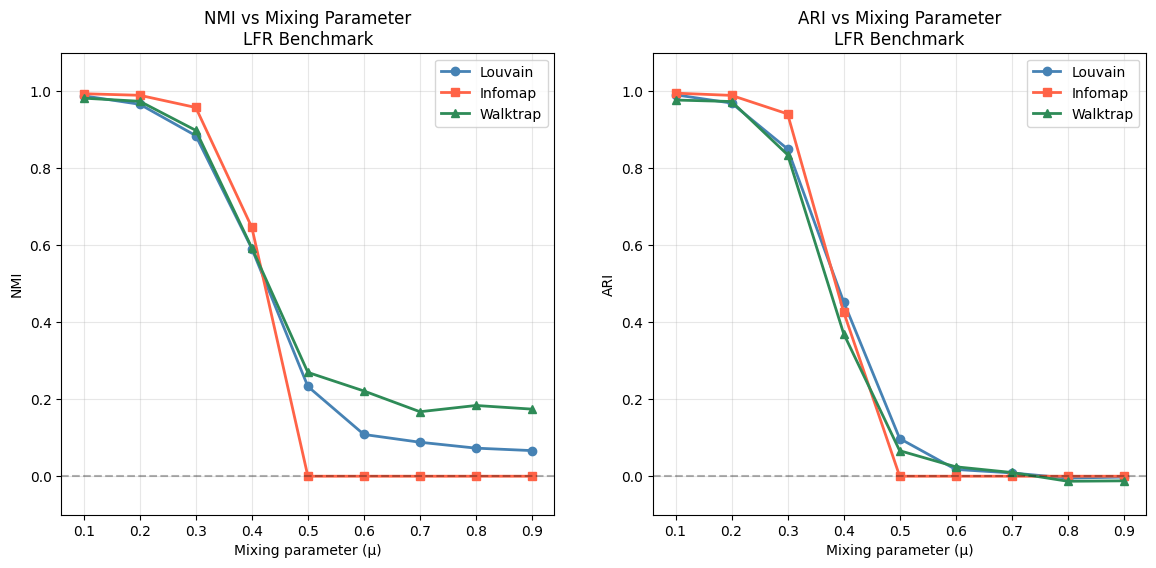

Figure 4.3b saved as 'figure_4_3b_lfr_nmi_ari.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mu_values = results["mu"]
colors = {"Louvain": "steelblue",
          "Infomap": "tomato",
          "Walktrap": "seagreen"}

# NMI plot
axes[0].plot(mu_values, results["louvain_nmi"],
             marker="o", color="steelblue",
             linewidth=2, label="Louvain")
axes[0].plot(mu_values, results["infomap_nmi"],
             marker="s", color="tomato",
             linewidth=2, label="Infomap")
axes[0].plot(mu_values, results["walktrap_nmi"],
             marker="^", color="seagreen",
             linewidth=2, label="Walktrap")
axes[0].set_xlabel("Mixing parameter (μ)")
axes[0].set_ylabel("NMI")
axes[0].set_title("NMI vs Mixing Parameter\nLFR Benchmark")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color="black", linestyle="--", alpha=0.3)
axes[0].set_ylim(-0.1, 1.1)

# ARI plot
axes[1].plot(mu_values, results["louvain_ari"],
             marker="o", color="steelblue",
             linewidth=2, label="Louvain")
axes[1].plot(mu_values, results["infomap_ari"],
             marker="s", color="tomato",
             linewidth=2, label="Infomap")
axes[1].plot(mu_values, results["walktrap_ari"],
             marker="^", color="seagreen",
             linewidth=2, label="Walktrap")
axes[1].set_xlabel("Mixing parameter (μ)")
axes[1].set_ylabel("ARI")
axes[1].set_title("ARI vs Mixing Parameter\nLFR Benchmark")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color="black", linestyle="--", alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

plt.savefig('/content/figure_4_3b_lfr_nmi_ari.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.3b saved as 'figure_4_3b_lfr_nmi_ari.png'")

## **Visualization of the network at two extreme mu values**

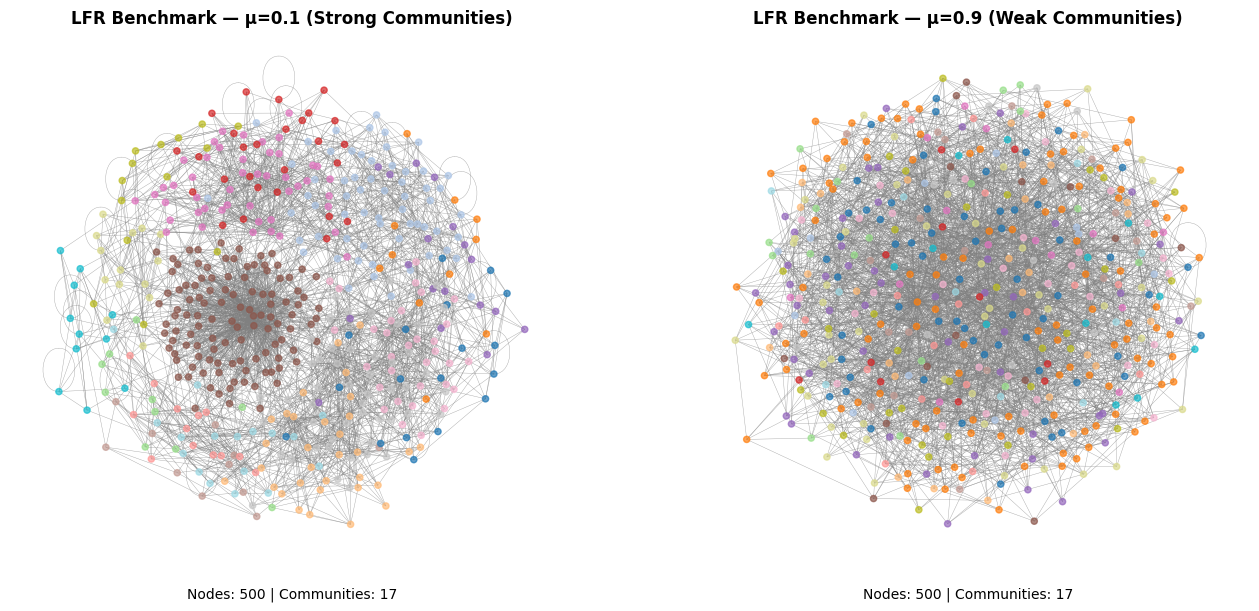

Figure 4.3b saved as 'figure_4_3b_lfr_m=0.1_m=0.9'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mu_values_viz = [0.1, 0.9]
titles = ["LFR Benchmark — μ=0.1 (Strong Communities)",
          "LFR Benchmark — μ=0.9 (Weak Communities)"]

for idx, mu in enumerate(mu_values_viz):

    # generate network
    G_viz = nx.LFR_benchmark_graph(
        n=500,
        tau1=3,
        tau2=1.5,
        mu=mu,
        average_degree=10,
        min_community=10,
        max_iters=10000,
        seed=1
    )

    # extract ground truth communities
    gt_communities_viz = list(set([
        frozenset(G_viz.nodes[v]["community"])
        for v in G_viz.nodes()
    ]))

    # assign color to each node based on community
    community_colors = {}
    colormap = plt.cm.get_cmap("tab20", len(gt_communities_viz))
    for i, community in enumerate(gt_communities_viz):
        for node in community:
            community_colors[node] = colormap(i)

    node_colors = [community_colors[node] for node in G_viz.nodes()]

    # use Kamada Kawai layout
    pos = nx.kamada_kawai_layout(G_viz)

    # draw
    nx.draw(G_viz, pos,
            node_color=node_colors,
            node_size=20,
            edge_color="gray",
            alpha=0.7,
            width=0.3,
            with_labels=False,
            ax=axes[idx])

    axes[idx].set_title(titles[idx], fontsize=12, fontweight="bold")
    axes[idx].text(0.5, -0.05,
                   f"Nodes: 500 | Communities: {len(gt_communities_viz)}",
                   transform=axes[idx].transAxes,
                   ha="center", fontsize=10)

plt.savefig('/content/figure_4_3b_lfr_m=0.1_m=0.9.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.3b saved as 'figure_4_3b_lfr_m=0.1_m=0.9'")

## **PART 2 - Effect of number of nodes**

In [ ]:

# Fix mu=0.3 and vary n from 100 to 2000
node_values = [100, 250, 500, 750, 1000, 1500, 2000]

# store results
results_nodes = {
    "n": [],
    "louvain_nmi": [], "louvain_ari": [],
    "infomap_nmi": [], "infomap_ari": [],
    "walktrap_nmi": [], "walktrap_ari": []
}

for n in node_values:
  print(f"\nRunning n={n}")

  try:
    G = nx.LFR_benchmark_graph(
        n=n,
        tau1=3,
        tau2=1.5,
        mu=0.3, # medium difficulty
        average_degree=10,
        min_community=20,
        max_iters=10000,
        seed=1
    )
  except Exception as e:
    print(f" Failed for n={n}: {e}")
    continue

  # basic info
  print(f" Nodes: {G.number_of_nodes()}")
  print(f" Edges: {G.number_of_edges()}")

  # extract ground truth
  gt_communities = list(set([
      frozenset(G.nodes[v]["community"])
      for v in G.nodes()
  ]))
  print(f"Ground truth communities: {len(gt_communities)}")

  # convert ground truth to cdlib
  gt = NodeClustering(
      communities=[list(c) for c in gt_communities],
      graph=G,
      method_name="ground_truth"
  )

  # run algorithms
  louvain = algorithms.louvain(G)
  infomap = algorithms.infomap(G)
  walktrap = algorithms.walktrap(G)

  # store results
  results_nodes["n"].append(n)
  results_nodes["louvain_nmi"].append(
      evaluation.normalized_mutual_information(louvain, gt).score)
  results_nodes["louvain_ari"].append(
      evaluation.adjusted_rand_index(louvain, gt).score)
  results_nodes["infomap_nmi"].append(
      evaluation.normalized_mutual_information(infomap, gt).score)
  results_nodes["infomap_ari"].append(
      evaluation.adjusted_rand_index(infomap, gt).score)
  results_nodes["walktrap_nmi"].append(
      evaluation.normalized_mutual_information(walktrap, gt).score)
  results_nodes["walktrap_ari"].append(
      evaluation.adjusted_rand_index(walktrap, gt).score)

print("\nn   | Louvain NMI | Infomap NMI | Walktrap NMI")
print("----|-------------|-------------|-------------")
for i, n in enumerate(results_nodes["n"]):
  print(f"{n}   | {results_nodes['louvain_nmi'][i]:.4f} | {results_nodes['infomap_nmi'][i]:.4f} | {results_nodes['walktrap_nmi'][i]:.4f}")

print("\nn   | Louvain ARI | Infomap ARI | Walktrap ARI")
print("----|-------------|-------------|-------------")
for i, n in enumerate(results_nodes["n"]):
  print(f"{n}   | {results_nodes['louvain_ari'][i]:.4f} | {results_nodes['infomap_ari'][i]:.4f} | {results_nodes['walktrap_ari'][i]:.4f}")


Running n=100
 Nodes: 100
 Edges: 516
Ground truth communities: 3

Running n=250
 Nodes: 250
 Edges: 1397
Ground truth communities: 6

Running n=500
 Nodes: 500
 Edges: 2976
Ground truth communities: 10

Running n=750
 Nodes: 750
 Edges: 4310
Ground truth communities: 21

Running n=1000
 Failed for n=1000: Could not assign communities; try increasing min_community

Running n=1500
 Nodes: 1500
 Edges: 8844
Ground truth communities: 29

Running n=2000
 Nodes: 2000
 Edges: 11888
Ground truth communities: 37

n   | Louvain NMI | Infomap NMI | Walktrap NMI
----|-------------|-------------|-------------
100   | 0.2105 | 0.0000 | 0.3214
250   | 0.7756 | 0.8272 | 0.7025
500   | 0.8529 | 0.9331 | 0.8581
750   | 0.9393 | 0.9785 | 0.9150
1500   | 0.9414 | 0.9768 | 0.9248
2000   | 0.9432 | 0.9715 | 0.9279

n   | Louvain ARI | Infomap ARI | Walktrap ARI
----|-------------|-------------|-------------
100   | 0.1278 | 0.0000 | 0.2591
250   | 0.7742 | 0.8423 | 0.7050
500   | 0.7875 | 0.9216 | 0.8287


## **Plot Visualization**

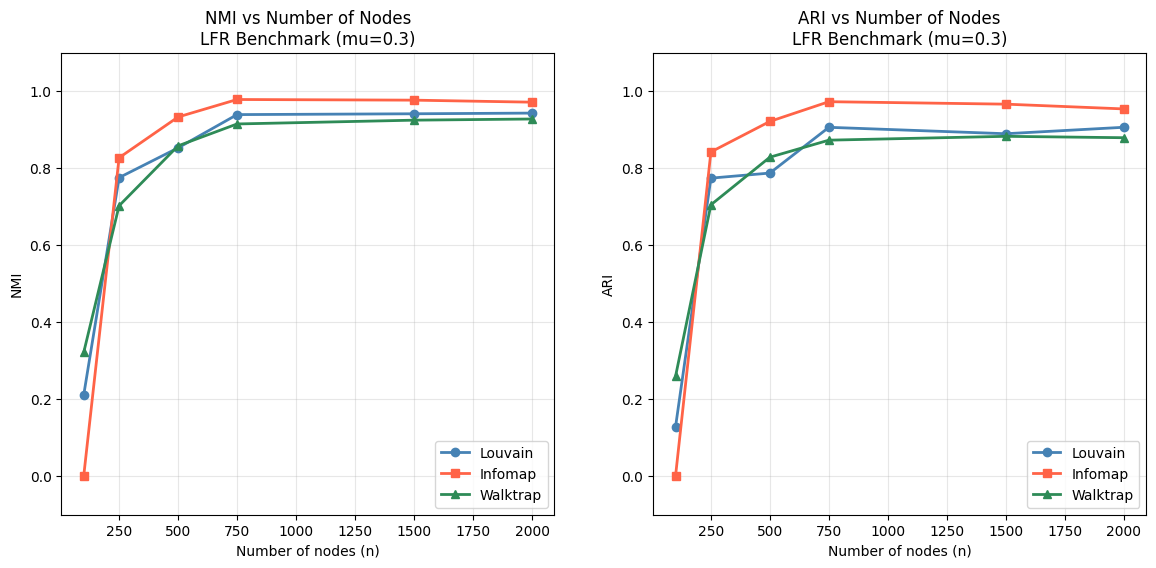

Figure 4.3c saved as 'figure_4_3c_lfr_nmi_ari.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

n_values = results_nodes["n"]

# NMI plot
axes[0].plot(n_values, results_nodes["louvain_nmi"],
             marker="o", color="steelblue",
             linewidth=2, label="Louvain")
axes[0].plot(n_values, results_nodes["infomap_nmi"],
             marker="s", color="tomato",
             linewidth=2, label="Infomap")
axes[0].plot(n_values, results_nodes["walktrap_nmi"],
             marker="^", color="seagreen",
             linewidth=2, label="Walktrap")
axes[0].set_xlabel("Number of nodes (n)")
axes[0].set_ylabel("NMI")
axes[0].set_title("NMI vs Number of Nodes\nLFR Benchmark (mu=0.3)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.1)

# ARI plot
axes[1].plot(n_values, results_nodes["louvain_ari"],
             marker="o", color="steelblue",
             linewidth=2, label="Louvain")
axes[1].plot(n_values, results_nodes["infomap_ari"],
             marker="s", color="tomato",
             linewidth=2, label="Infomap")
axes[1].plot(n_values, results_nodes["walktrap_ari"],
             marker="^", color="seagreen",
             linewidth=2, label="Walktrap")
axes[1].set_xlabel("Number of nodes (n)")
axes[1].set_ylabel("ARI")
axes[1].set_title("ARI vs Number of Nodes\nLFR Benchmark (mu=0.3)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

plt.savefig('/content/figure_4_3c_lfr_nmi_ari.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.3c saved as 'figure_4_3c_lfr_nmi_ari.png'")

## **Visualization of the network at two extreme nodes values**

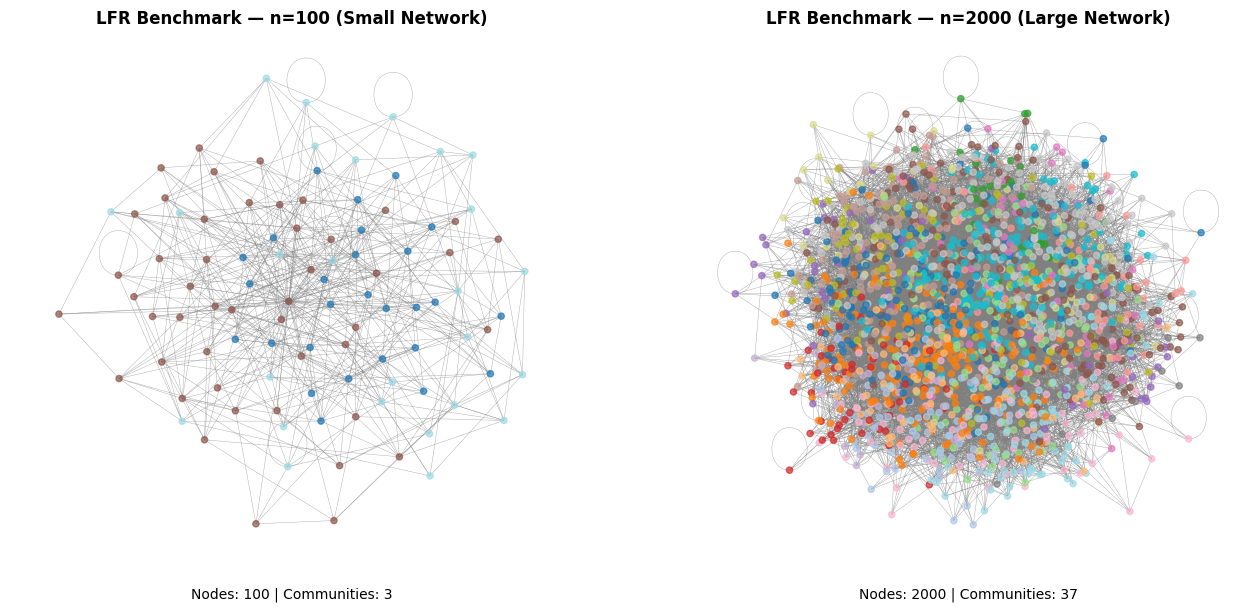

Figure 4.3d saved as 'figure_4_3b_lfr_n=100_n=2000'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

nodes_values_viz = [100, 2000]
titles = ["LFR Benchmark — n=100 (Small Network)",
          "LFR Benchmark — n=2000 (Large Network)"]

for idx, nodes in enumerate(nodes_values_viz):

    # generate network
    G_viz = nx.LFR_benchmark_graph(
        n=nodes,
        tau1=3,
        tau2=1.5,
        mu=0.3,
        average_degree=10,
        min_community=20,
        max_iters=10000,
        seed=1
    )

    # extract ground truth communities
    gt_communities_viz = list(set([
        frozenset(G_viz.nodes[v]["community"])
        for v in G_viz.nodes()
    ]))

    # assign color to each node based on community
    community_colors = {}
    colormap = plt.cm.get_cmap("tab20", len(gt_communities_viz))
    for i, community in enumerate(gt_communities_viz):
        for node in community:
            community_colors[node] = colormap(i)

    node_colors = [community_colors[node] for node in G_viz.nodes()]

    # use Kamada Kawai layout
    pos = nx.spring_layout(G_viz, seed=1)

    # draw
    nx.draw(G_viz, pos,
            node_color=node_colors,
            node_size=20,
            edge_color="gray",
            alpha=0.7,
            width=0.3,
            with_labels=False,
            ax=axes[idx])

    axes[idx].set_title(titles[idx], fontsize=12, fontweight="bold")
    axes[idx].text(0.5, -0.05,
                   f"Nodes: {nodes} | Communities: {len(gt_communities_viz)}", # Corrected hardcoded node count
                   transform=axes[idx].transAxes,
                   ha="center", fontsize=10)


plt.savefig('/content/figure_4_3d_lfr_n=100_n=2000.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4.3d saved as 'figure_4_3b_lfr_n=100_n=2000'")

## **Effect of vary edge density**

In [ ]:
# Part 2 -> vary average degree (edge density)
# fix n=500, mu=0.3, vary average_degree
degree_values = [5, 8, 10, 15, 20, 30, 50]

# store results
results_degree = {
    "degree": [],
    "louvain_nmi": [], "louvain_ari": [],
    "infomap_nmi": [], "infomap_ari": [],
    "walktrap_nmi": [], "walktrap_ari": []
}

for avg_deg in degree_values:
    print(f"Running average_degree={avg_deg}")

    try:
        G = nx.LFR_benchmark_graph(
            n=500,
            tau1=3,
            tau2=1.5,
            mu=0.3, # medium difficulty
            average_degree=avg_deg,
            min_community=10, # Adjusted from 20 to 10
            max_iters=10000,
            seed=1
        )
    except Exception as e:
        print(f"  Failed for degree={avg_deg}: {e}")
        continue

    # basic info
    print(f" Nodes: {G.number_of_nodes()}")
    print(f" Edges: {G.number_of_edges()}")

    # extract ground truth
    gt_communities = list(set([
        frozenset(G.nodes[v]["community"])
        for v in G.nodes()
    ]))
    print(f"Ground truth communities: {len(gt_communities)}")

    # convert ground truth to cdlib
    gt = NodeClustering(
        communities=[list(c) for c in gt_communities],
        graph=G,
        method_name="ground_truth"
    )

    # run algorithms
    louvain = algorithms.louvain(G)
    infomap = algorithms.infomap(G)
    walktrap = algorithms.walktrap(G)

    # store results
    results_degree["degree"].append(avg_deg)
    results_degree["louvain_nmi"].append(
        evaluation.normalized_mutual_information(louvain, gt).score)
    results_degree["louvain_ari"].append(
        evaluation.adjusted_rand_index(louvain, gt).score)
    results_degree["infomap_nmi"].append(
        evaluation.normalized_mutual_information(infomap, gt).score)
    results_degree["infomap_ari"].append(
        evaluation.adjusted_rand_index(infomap, gt).score)
    results_degree["walktrap_nmi"].append(
        evaluation.normalized_mutual_information(walktrap, gt).score)
    results_degree["walktrap_ari"].append(
        evaluation.adjusted_rand_index(walktrap, gt).score)

print("\nDegree   | Louvain NMI | Infomap NMI | Walktrap NMI")
print("---------|-------------|-------------|-------------")
for i, degree_val in enumerate(results_degree["degree"]):
    print(f"{degree_val:<8} | {results_degree['louvain_nmi'][i]:.4f} | {results_degree['infomap_nmi'][i]:.4f} | {results_degree['walktrap_nmi'][i]:.4f}")

print("\nDegree   | Louvain ARI | Infomap ARI | Walktrap ARI")
print("---------|-------------|-------------|-------------")
for i, degree_val in enumerate(results_degree["degree"]):
    print(f"{degree_val:<8} | {results_degree['louvain_ari'][i]:.4f} | {results_degree['infomap_ari'][i]:.4f} | {results_degree['walktrap_ari'][i]:.4f}")

Running average_degree=5
 Nodes: 500
 Edges: 1030
Ground truth communities: 28
Running average_degree=8
 Nodes: 500
 Edges: 1678
Ground truth communities: 14
Running average_degree=10
 Nodes: 500
 Edges: 2865
Ground truth communities: 17
Running average_degree=15
  Failed for degree=15: Could not assign communities; try increasing min_community
Running average_degree=20
 Nodes: 500
 Edges: 6123
Ground truth communities: 8
Running average_degree=30
 Nodes: 500
 Edges: 8716
Ground truth communities: 8
Running average_degree=50
  Failed for degree=50: Could not assign communities; try increasing min_community

Degree   | Louvain NMI | Infomap NMI | Walktrap NMI
---------|-------------|-------------|-------------
5        | 0.4307 | 0.6008 | 0.5206
8        | 0.6610 | 0.7256 | 0.5838
10       | 0.9249 | 0.9569 | 0.8983
20       | 0.8563 | 0.0000 | 0.8397
30       | 0.7224 | 0.0000 | 0.6978

Degree   | Louvain ARI | Infomap ARI | Walktrap ARI
---------|-------------|-------------|----------

## **Plot Visualization**

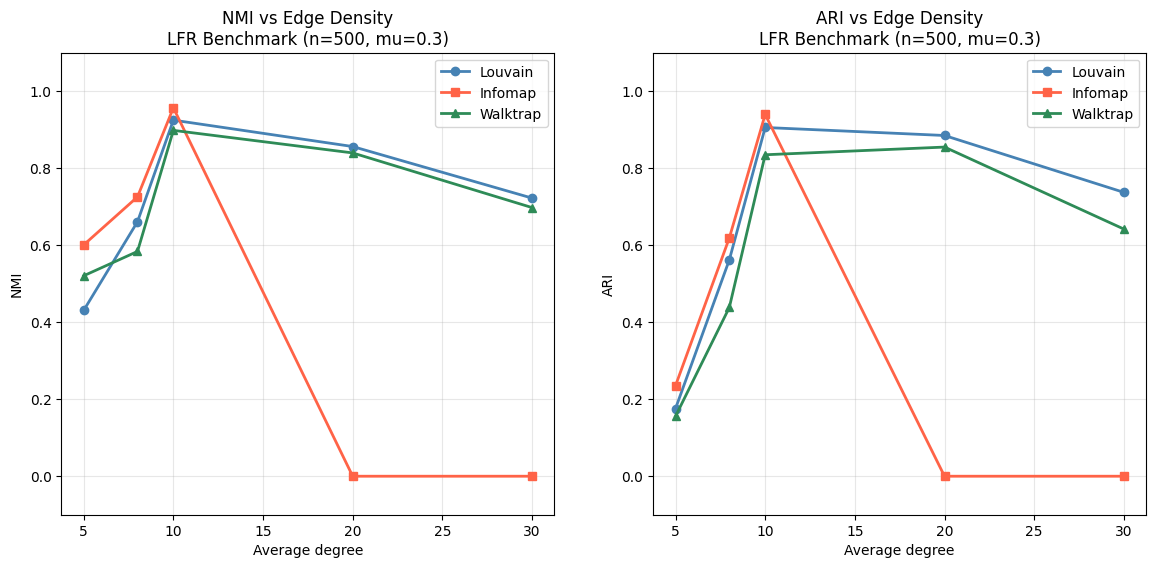

Figure 4.3e saved as 'figure_4_3e_lfr_nmi_ari.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

deg_values = results_degree["degree"]

# NMI plot
axes[0].plot(deg_values, results_degree["louvain_nmi"],
             marker="o", color="steelblue",
             linewidth=2, label="Louvain")
axes[0].plot(deg_values, results_degree["infomap_nmi"],
             marker="s", color="tomato",
             linewidth=2, label="Infomap")
axes[0].plot(deg_values, results_degree["walktrap_nmi"],
             marker="^", color="seagreen",
             linewidth=2, label="Walktrap")
axes[0].set_xlabel("Average degree")
axes[0].set_ylabel("NMI")
axes[0].set_title("NMI vs Edge Density\nLFR Benchmark (n=500, mu=0.3)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.1)

# ARI plot
axes[1].plot(deg_values, results_degree["louvain_ari"],
             marker="o", color="steelblue",
             linewidth=2, label="Louvain")
axes[1].plot(deg_values, results_degree["infomap_ari"],
             marker="s", color="tomato",
             linewidth=2, label="Infomap")
axes[1].plot(deg_values, results_degree["walktrap_ari"],
             marker="^", color="seagreen",
             linewidth=2, label="Walktrap")
axes[1].set_xlabel("Average degree")
axes[1].set_ylabel("ARI")
axes[1].set_title("ARI vs Edge Density\nLFR Benchmark (n=500, mu=0.3)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

plt.savefig('/content/figure_4_3e_lfr_nmi_ari.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.3e saved as 'figure_4_3e_lfr_nmi_ari.png'")

## **Visualization of the network at two extreme degree values**

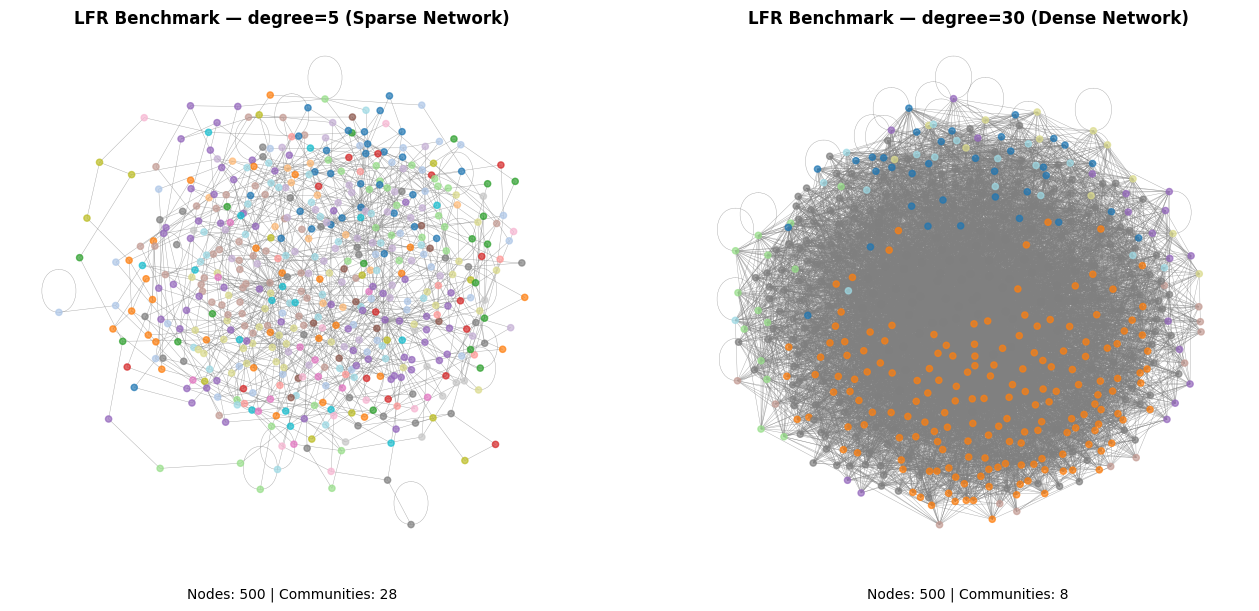

Figure 4.3f saved as 'figure_4_3f_lfr_d=5_d=30'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

degree_values_viz = [5, 30]
titles = ["LFR Benchmark — degree=5 (Sparse Network)",
          "LFR Benchmark — degree=30 (Dense Network)"]

for idx, degree in enumerate(degree_values_viz):

    # generate network
    G_viz = nx.LFR_benchmark_graph(
        n=500,
        tau1=3,
        tau2=1.5,
        mu=0.3,
        average_degree=degree,
        min_community=10,
        max_iters=10000,
        seed=1
    )

    # extract ground truth communities
    gt_communities_viz = list(set([
        frozenset(G_viz.nodes[v]["community"])
        for v in G_viz.nodes()
    ]))

    # assign color to each node based on community
    community_colors = {}
    colormap = plt.cm.get_cmap("tab20", len(gt_communities_viz))
    for i, community in enumerate(gt_communities_viz):
        for node in community:
            community_colors[node] = colormap(i)

    node_colors = [community_colors[node] for node in G_viz.nodes()]

    # use Kamada Kawai layout
    pos = nx.kamada_kawai_layout(G_viz)

    # draw
    nx.draw(G_viz, pos,
            node_color=node_colors,
            node_size=20,
            edge_color="gray",
            alpha=0.7,
            width=0.3,
            with_labels=False,
            ax=axes[idx])

    axes[idx].set_title(titles[idx], fontsize=12, fontweight="bold")
    axes[idx].text(0.5, -0.05,
                   f"Nodes: 500 | Communities: {len(gt_communities_viz)}",
                   transform=axes[idx].transAxes,
                   ha="center", fontsize=10)

plt.savefig('/content/figure_4_3f_lfr_d=5_d=30.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4.3f saved as 'figure_4_3f_lfr_d=5_d=30'")